****start analysis*****
Device: cpu
Memory reduce
Building Hypergraph.......
offset:  1463


C:\Users\debas\AppData\Local\Temp\ipykernel_17520\3668785407.py:523: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(entity_col, group_keys = False).apply(_roll)


Buid Heterogeneous Graph............
Fusion Model...
Epoch 01: Loss = 10.70845| Acc =0.4213 | Prec = 0.0172 | Rec =0.5333| F1= 0.0334|  AUC = 0.4679
Epoch 02: Loss = 0.57502| Acc =0.9812 | Prec = 0.0000 | Rec =0.0000| F1= 0.0000|  AUC = 0.5109
Epoch 03: Loss = 0.74598| Acc =0.9812 | Prec = 0.0000 | Rec =0.0000| F1= 0.0000|  AUC = 0.5110
Epoch 04: Loss = 0.80265| Acc =0.9812 | Prec = 0.0000 | Rec =0.0000| F1= 0.0000|  AUC = 0.5210
Epoch 05: Loss = 0.79869| Acc =0.9812 | Prec = 0.0000 | Rec =0.0000| F1= 0.0000|  AUC = 0.5316
Epoch 06: Loss = 0.78379| Acc =0.9812 | Prec = 0.0000 | Rec =0.0000| F1= 0.0000|  AUC = 0.5521
Epoch 07: Loss = 0.78361| Acc =0.9812 | Prec = 0.0000 | Rec =0.0000| F1= 0.0000|  AUC = 0.5569
Epoch 08: Loss = 0.78530| Acc =0.9812 | Prec = 0.0000 | Rec =0.0000| F1= 0.0000|  AUC = 0.5590
Epoch 09: Loss = 0.78092| Acc =0.9838 | Prec = 1.0000 | Rec =0.1333| F1= 0.2353|  AUC = 0.5651
Epoch 10: Loss = 0.77994| Acc =0.9825 | Prec = 1.0000 | Rec =0.0667| F1= 0.1250|  AUC = 0.5

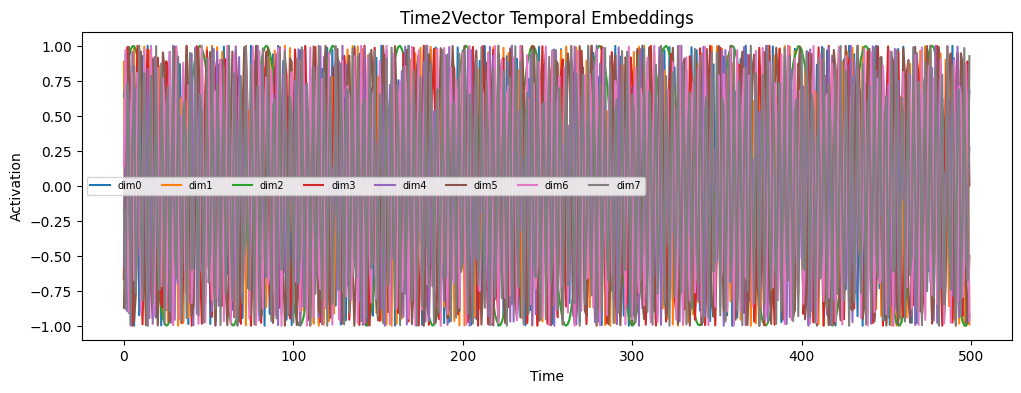

Extracting fraud ring for transaction.... 600 ......
I am before hops
i am now at return G
Saved interactive graph


In [1]:
##My experiment - mini batch neighbor sampling + Hybrid model (Hypergraph NN + Heterogeneous Graph Transformers (HGTConv))#
###A two-hop heterogeneous neighbourhood centred on a flagged seed transaction from the IEEE-CIS test set, extracted
## by our temporally-causal subgraph builder 

import torch, sys, platform
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.data import HeteroData
from torch_geometric.nn import HGTConv    #### Heterogeneous Graph Transformers (HGTConv)
from torch_geometric.nn import Linear
from torch.utils.data import Dataset, DataLoader
from pyvis.network import Network

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ( average_precision_score, confusion_matrix, accuracy_score)
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import pandas as pdt
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import networkx as nx
import torch_geometric.typing
from torch_geometric.loader import NeighborLoader 
import random
from IPython.display import display, HTML

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Feature dims and training
ENTITYDIM = 32
TXN_FEAT_DIM = 2
TIME_DIM = 8   ### Dimention of Time2Vec encoding
HIDDEN_DIM = 128
OUT_EMB_DIM = 32
LR = 2e-3
EPOCHS = 20
SEED = 42
TRAINROWS = 1000  ## if we select None here, then that would consider full dataset.
GRAPH_HOPS_FOR_RING = 2
RING_TXN_ID = 600

### mini batch training - Neighbor sampling
BATCH_SIZE = 256 # batch size for neighbor sampling on hetero-graph
NEIGHBORS = [20, 15]  #number of neighbors to sample at 1-hop and 2-hop for HGTConv( for a 2 layer GNN)

## Reproducibility
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

##Reduce Memory usage here ## Optimize Data types
def reduce_mem_usage(df):
     for col in df.columns:
         if not pd.api.types.is_object_dtype(df[col]):
             df[col] = df[col].astype(np.float32)
     print("Memory reduce")
     return df
        
def normalizeArray(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() +1e-6)

def compute_metrics(y_true, y_pred):
    y_bin = (y_pred >= 0.5).astype(int)
    try:
        auc = roc_auc_score(y_true,y_pred)
    except:
        auc = 0.0

    acc = accuracy_score(y_true, y_bin)
    prec = precision_score(y_true, y_bin, zero_division = 0)
    rec = recall_score(y_true, y_bin, zero_division = 0)
    f1 = f1_score(y_true, y_bin, zero_division = 0)
    return acc, prec, rec, f1, auc
        

## Temporal Encoding ##
## vector representation for a scalar time input. This class will help to capture evolving fraud patterns.##
class Time2Vector(nn.Module):
    def __init__(self, out_dim = TIME_DIM):
        super().__init__()
        self.w = nn.Parameter(torch.randn(1, out_dim))
        self.b = nn.Parameter(torch.randn(1, out_dim))
                
    def forward(self, t):   ##t: shape[N, 1] time value per sample
        return torch.sin(t * self.w  + self.b)   #### Output: shape[N, TIME_DIM] with sinusoidal time encoding
        
class TemporalAttention(nn.Module):
    def __init__(self, time_dim = TIME_DIM):
        super().__init__()
        self.att = nn.Linear(time_dim, time_dim, bias = False)  ## Learn wiights to score each time component

    def forward(self, time_emb):
        scores = self.att(time_emb)
        weights = torch.softmax(scores, dim =1)  ## attention weights across time dimensions
        return time_emb * weights, weights

   
###########visualization#######
def plot_time2vec(time2Vec, t_min, t_max, steps =500):
    t = torch.linspace(t_min, t_max, steps).reshape(-1, 1).to(DEVICE)
    with torch.no_grad():
        v = time2Vec(t).cpu().numpy()

    plt.figure(figsize = (12,4))
    for i in range(v.shape[1]):
        plt.plot(v[:, i], label = f"dim{i}")
    
    plt.title("Time2Vector Temporal Embeddings")
    plt.xlabel("Time")
    plt.ylabel("Activation")
    plt.legend(ncol = TIME_DIM, fontsize = 7)
    plt.show()


############ FRAUD and Non Fraud temporal attention ###

def plot_temporal_attention(fraud_att, nonfraud_att):
    plt.figure(figsize = (10,4))
    plt.plot(fraud_att.mean(axis = 0), marker = "o", label ="Fraud")
    plt.plot(nonfraud_att.mean(axis = 0), marker = "o", label ="Non-Fraud")
    plt.title("Temporal Attension : which Time Patterns Matter?")
    plt.legend()
    plt.grid(True)
    plt.show()

    

### My step to build Heterogeneous Hypergraph############

##data = HeteroData()

###TO Support millions transactions Fraud detection## trying to build true hypergraph

#### HYPERGRAPH MODEL#########################

class DualHypergraph:
    def __init__( self, df):
        self.df = df.copy().reset_index(drop = True)
         ### Define attributes that will form hyperedges (including composite attributes)
        self.df["time_bin"] = (self.df["TransactionDT"] // (60*5)).astype(str)
            #hyper_attrs = ["card1","ProductCD","addr1","P_emaildomain"]
        ###priority fraud attributes at table
        self.attr_cols = ["card1","addr1","P_emaildomain","DeviceInfo","DeviceType","id_30","id_31","ProductCD", "time_bin"]

        self.df["combo_dev_ip"] = self.df["DeviceInfo"].astype(str) +"_"+ self.df["id_31"].astype(str)
        self.df["combo_card_addr"] = self.df["card1"].astype(str) +"_"+ self.df["addr1"].astype(str)
        #df["combo_email_addr"] = df["P_emaildomain"].astype(str) +"_"+ df["addr1"].astype(str)
        self.attr_cols += ["combo_dev_ip", "combo_card_addr"]

        for c in self.attr_cols:
            self.df[c] = self.df[c].astype(str)

        #self.df = df 
        self.num_nodes = len(self.df)
        self.hyperedge_offsets = {}
        self.value_maps = {}
        offset = 0

        ###build hyperedge index spaces
        for col in self.attr_cols:
            #cats = self.df[col].astype("category").cat.categories
            uniqueVal = pd.Series(self.df[col].unique()).astype(str)
            mapping = {v:i for i,v in enumerate(uniqueVal)}
            self.value_maps[col] = mapping
            self.hyperedge_offsets[col] = offset
            offset += len(mapping)

        self.total_hyperedges = offset
        print("offset: ", offset)

        ### build Hypergraph incidence marix
        H_row , H_col = [], []
        for txn_id, row in self.df.iterrows():
            for col in self.attr_cols:
                hid = self.hyperedge_offsets[col] + self.value_maps[col][row[col]]
                H_row.append(txn_id)
                H_col.append(hid)

        self.H_row = torch.tensor(H_row, dtype = torch.long) 
        self.H_col = torch.tensor(H_col, dtype = torch.long)    
        self.labels = torch.tensor(self.df["isFraud"].fillna(0).values, dtype = torch.float32)    

                
class HypergraphNN(nn.Module):
    def __init__(self, num_nodes, num_hyperedges, dim =ENTITYDIM , hidden = HIDDEN_DIM, heads = 4):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, dim)  #Embedding for transaction
        self.he_emb = nn.Embedding(num_hyperedges, dim)  # Embeding for hyperedges
        self.proj = nn.Linear(dim*2, hidden)
        #self.att = nn.MultiheadAttention(hidden, heads, batch_first = True)
        self.attn = nn.MultiheadAttention(embed_dim = hidden, num_heads=heads, batch_first = True)

    def forward(self, H_row, H_col, batch_nodes):
        mask = torch.isin(H_row, batch_nodes)
        nodes = H_row[mask]
        hedges = H_col[mask]
        N = batch_nodes.shape[0]
        if N == 0:
            return torch.zeros((0, self.proj.out_features), device = batch_nodes.device )
            
        counts = nodes.bincount(minlength = N).cpu()
        max_deg = counts.max().item()

        M = torch.zeros((N, max_deg, self.node_emb.embedding_dim * 2), device = batch_nodes.device )
        for i, n in enumerate(batch_nodes):
            idx = (nodes == n).nonzero(as_tuple = False).view(-1)
            if idx.numel() == 0:
                continue
            ne = self.node_emb(n)
            he = self.he_emb(hedges[idx])
            node_rep = ne.expand(he.size(0), -1)
            M[i, :he.size(0), :] = torch.cat([node_rep, he], dim = 1)

        h = F.relu(self.proj(M)) 
        att_out,_ = self.attn(h,h,h)
        hyper_embeddings = att_out.mean(dim = 1)
        return hyper_embeddings    ### hyper graph embedding for each transaction
            

################
# Heterogeneous graph builder
################
def build_hetero_graph(df):
    print("Buid Heterogeneous Graph............")
    data = HeteroData()

    amt = df["TransactionAmt"].values
    tdt = df["TransactionDT"].values
    tdt_norm = (tdt - tdt.min()) / (tdt.max() - tdt.min() + 1e-6)
    
    ## ADD  Temporal evolution features

    delta_t = df["delta_t"].values
    txn_count_1h = df["txn_count_1h"].values
    txn_count_24h = df["txn_count_24h"].values
    amt_zscore = df["amt_zscore"].values

       
    txn_code = df["card1"].astype("category").cat.codes.values
    
    #num_devices = df["DeviceInfo"].astype("category").nunique()
    
    #data["transaction"].node_id = torch.arange(len(df))

    data["transaction"].x = torch.tensor(
        np.column_stack([amt, tdt_norm,delta_t, txn_count_1h,txn_count_24h, amt_zscore ]),
        #dtype = torch.long
        dtype = torch.float32 )

    data["transaction"].y = torch.tensor(
        df["isFraud"].values, dtype = torch.long
    )

        
    num_txn = len(txn_code)


    ## fake device IDs for example

    #Device features
    df["device_code"] = df["DeviceInfo"].astype("category").cat.codes
    num_devices = df["device_code"].max() + 1
    data["device"].x = torch.arange(num_devices,dtype = torch.long)

    df["ip_code"] = df["id_31"].astype("category").cat.codes
    ip_count = df["ip_code"].max() + 1
    data["ip"].x = torch.arange(ip_count, dtype = torch.long)

    ###Added Merchant and Location node types
    df["merchant_code"] = df["ProductCD"].astype("category").cat.codes
    num_merchants =  df["merchant_code"].max() + 1
    data["merchant"].x = torch.arange(num_merchants,dtype = torch.long)

    df["location_code"] = df["addr1"].astype("category").cat.codes
    num_locations =  df["location_code"].max() + 1
    data["location"].x = torch.arange(num_locations,dtype = torch.long)
    
         
    ### build edge transaction -> device
    #### connect transaction -> device placeholder
    ti = torch.tensor(df.index.values, dtype = torch.long) 
    di = torch.tensor(df["device_code"].values, dtype = torch.long)
    data[("transaction" , "uses", "device")].edge_index = torch.stack([ti, di])
    data[("device" , "used_by", "transaction")].edge_index = torch.stack([di, ti])

    ii = torch.tensor(df["ip_code"].values, dtype = torch.long)
    data["transaction", "originates", "ip"].edge_index = torch.stack([ti, ii])
    data["ip", "source_of", "transaction"].edge_index = torch.stack([ii, ti])

    mi = torch.tensor(df["merchant_code"].values, dtype = torch.long)
    data["transaction", "done_at", "merchant"].edge_index = torch.stack([ti, mi])
    data["merchant", "has_transaction", "transaction"].edge_index = torch.stack([mi, ti])

    li = torch.tensor(df["location_code"].values, dtype = torch.long)
    data["transaction", "occutrs_in", "location"].edge_index = torch.stack([ti, li])
    data["location", "loc_of", "transaction"].edge_index = torch.stack([li, ti])

    
    node_sizes = {
        "transaction": num_txn,
        "device": num_devices,
        "ip": ip_count,
        "merchant": num_merchants,
        "location": num_locations
        
    }

    return data, node_sizes


############################
## Heterogeneous GNN (HGTConv)
############################
class HeteroModel(nn.Module):
    def __init__(self, metadata, node_sizes,tx_feat_dim, hidden = HIDDEN_DIM, heads =4, debug = False):
        super().__init__()
        node_types, _ = metadata
        self.hidden = hidden
        self.debug = debug
        self.enc = nn.ModuleDict()
        for nt in node_types:
            if nt == "transaction":
                self.enc[nt] = nn.Linear(tx_feat_dim + TIME_DIM,  hidden)
            else:
                self.enc[nt] = nn.Embedding(node_sizes[nt], hidden)
        ## in_channels = the dimension of input node embeddings to the HGT layer
        ## out_channels = the dimension of output node embeddings produced by the layer

        self.time2vec = Time2Vector(out_dim = TIME_DIM)  ## encode raw time
        self.temp_att = TemporalAttention( time_dim = TIME_DIM)
        self.hgt = HGTConv(in_channels = hidden, out_channels = hidden, metadata = metadata, heads = heads)
        self.transaction_time = None
        
    def _encode_node(self, nt: str, x: torch.Tensor) -> torch.Tensor:
        mod = self.enc[nt]
        if isinstance(mod, nn.Embedding):
            if x.numel() == 0:
                return None
            return mod(x.long())
        else:
            if x.numel() == 0:
                return None
            return mod(x.float())
            
    def forward(self, data):
        x_dict = {}
        for ntype, x in data.x_dict.items():
            if ntype == "transaction":
                tx_feats = x.float()
                if hasattr(data[ntype], "time"):
                    t_raw = data[ntype].time.view(-1, 1).to(x.device)
                else:
                    t_raw = self.transaction_time[data[ntype].n_id].view(-1, 1).to(x.device)
                t_emb = self.time2vec(t_raw)
                t_att_emb, _ = self.temp_att(t_emb)
                tx_input = torch.cat([ tx_feats, t_att_emb], dim =1) ### concatenate features with time embedding
                #x_dict[ntype]  = tx_input
                x_dict[ntype] = self.enc["transaction"](tx_input)
            else:
                 #x_dict[ntype] = x.long()
                x_dict[ntype] = self.enc[ntype](x.long())
                
        edge_index_dict = { rel: ei for rel, ei in data.edge_index_dict.items() if ei.size(1) > 0  }
        if not edge_index_dict:
            return x_dict.get("transaction", torch.empty(0, self.type_enc["transaction"].out_features, device = DEVICE))

        h_dict = self.hgt(x_dict, edge_index_dict)
        return h_dict["transaction"]
                
                
##################
### Fusion Model (HyperGraph + HGT)
###################

class Fusion(nn.Module):
    def __init__(self, hidden_dim = HIDDEN_DIM):
        super().__init__()
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, hyper_emb, hetero_emb):
        return torch.sigmoid(self.fc(torch.cat([hyper_emb, hetero_emb], dim = 1))).squeeze(1) 

#####################
#### Training
#####################

class TxnDataset(Dataset):
    def __init__(self, labels): self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return i, self.labels[i]

#### Define training loop using mini batch neighbor sampling
def train_hybrid(hyp_model, het_model, fusion_model, hypergraph, hetero_data, epochs, batch_size):
    input_nodes = ("transaction", hetero_data["transaction"].train_mask)
    loader = NeighborLoader(hetero_data, input_nodes = input_nodes, num_neighbors = NEIGHBORS, batch_size = batch_size, shuffle = True)
    optimizer = torch.optim.Adam(list(hyp_model.parameters()) + list(het_model.parameters()) + list(fusion_model.parameters()), lr =LR)
    loss_fn = nn.BCELoss()
    
    for epoch in range(1, epochs + 1):
        #model.train()
        hyp_model.train()
        het_model.train()
        fusion_model.train()
        total_loss = 0.0
        all_preds =[]
        all_labels = []
        for batch in loader:
            batch = batch.to(DEVICE)
            seed_count = batch["transaction"].batch_size
            seed_nodes = batch["transaction"].n_id[:seed_count]
            hyper_emb = hyp_model(hypergraph.H_row.to(DEVICE) , hypergraph.H_col.to(DEVICE) , seed_nodes)
            tx_emb_batch = het_model(batch)
            tx_emb_seeds = tx_emb_batch[:seed_count]
            
            ## Fusion prediction-> Fraud probabilities
            preds = fusion_model(hyper_emb, tx_emb_seeds)
            labels = batch["transaction"].y[:seed_count].to(DEVICE).float()
            loss = loss_fn(preds, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
                  
            total_loss += loss.item() * seed_count
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(labels.cpu().numpy())

        all_preds_np = np.concatenate(all_preds)
        all_labels_np = np.concatenate(all_labels)
        acc, prec, rec, f1, auc = compute_metrics(all_labels_np , all_preds_np) 
        avg_loss = total_loss / len(all_labels_np)

        print(f"Epoch {epoch:02d}: Loss = { avg_loss:.5f}"
              f"| Acc ={acc:.4f} | Prec = {prec:.4f} | Rec ={rec:.4f}"
              f"| F1= {f1:.4f}|  AUC = {auc:.4f}" )
        
  
        
def evaluate_model(hyp_model, het_model, fusion_model, hypergraph, hetero_data):

    hyp_model.eval()
    het_model.eval()
    fusion_model.eval()
    input_nodes = ("transaction", torch.arange(hypergraph.num_nodes))
    loader = NeighborLoader(hetero_data, input_nodes = input_nodes, num_neighbors = NEIGHBORS, batch_size = BATCH_SIZE, shuffle = False)

       
    all_preds =[]
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            seed_count = batch["transaction"].batch_size
            seed_nodes = batch["transaction"].n_id[:seed_count]
            hyper_emb = hyp_model(hypergraph.H_row.to(DEVICE) , hypergraph.H_col.to(DEVICE) , seed_nodes)
            tx_emb_batch = het_model(batch)
            tx_emb_seeds = tx_emb_batch[:seed_count]
            
            ## Fusion prediction-> Fraud probabilities
            preds = fusion_model(hyper_emb, tx_emb_seeds)
            labels = batch["transaction"].y[:seed_count].to(DEVICE).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds_np = np.concatenate(all_preds)
    all_labels_np = np.concatenate(all_labels)
    return compute_metrics(all_labels_np, all_preds_np)
        
############3 Add rolling behavirol features per entity  example card, user
def AddTemporalBehaFeatures(df, entity_col = "card1"):
    #### Assume Data Frame is sorted by time.
    df = df.copy()
    df["TransactionTime"] = pd.to_datetime(df["TransactionDT"], unit ="s", origin ="unix" , errors ="coerce")
    
    df = df.reset_index(drop =True)
    df = df.sort_values([entity_col, "TransactionTime"] , kind ="mergesort")

    #Time delta since previos transaction . delta_t per entity(seconds)
    df["delta_t"] = (
        df.groupby(entity_col)["TransactionTime"]
          .diff()
          .dt.total_seconds()
          .fillna(0.0)
          .clip(lower = 0)
          .astype("float32")
    )

    ## Time based Rolling transaction counts
    ##Rolling feature computed inside each group

    def _roll(g):
        g = g.copy()
        gi = g.set_index("TransactionTime")

        c1h = gi["TransactionDT"].rolling("1h").count()
        c24h = gi["TransactionDT"].rolling("24h").count()
        m24 = gi["TransactionAmt"].rolling("24h").mean()
        s24 = gi["TransactionAmt"].rolling("24h").std()

        ### back to the original (integer) index safely

        g["txn_count_1h"] = c1h.values.astype("float32")
        g["txn_count_24h"] = c24h.values.astype("float32")
        g["amt_mean_24h"] = m24.values.astype("float32")
        g["amt_std_24h"] = np.nan_to_num(s24.values , nan = 1.0).astype("float32")


        g["amt_zscore"] = ( 
            (g["TransactionAmt"] - g["amt_mean_24h"] ) / g["amt_std_24h"]
    ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype("float32")

        return g
    df = df.groupby(entity_col, group_keys = False).apply(_roll)
    ##Abrupt change detector
    
    return df

      
    ###############
    #####Metrics####
def eval_metrics(y_true: np.ndarray, y_prob: np.ndarray):
        y_pred = (y_prob >= 0.5).astype(int)
        return {
            "AUC": float(roc_auc_score( y_true,  y_prob)) if len(np.unique(y_true)) > 1 else float("nan"),
            "f1":  float(f1_score(y_true, y_pred)) if len(np.unique(y_pred)) > 1 else float("nan"),
            "precision": float(precision_score(y_true, y_pred, zero_division = 0)),
            "recall" :  float(recall_score (y_true, y_pred, zero_division = 0)) ,
            } 
    
              
### FRAUD RING DETECTION ####
#################################

def detect_fraud_ring(data: HeteroData, labels, txn_id: int, hops: int = GRAPH_HOPS_FOR_RING) -> nx.Graph:
    # Optimize fraud ring detector
    import networkx as nx
   
    num_txn = data["transaction"].num_nodes
    if txn_id < 0 or txn_id >= num_txn:
        raise IndexError(f"txn_id {txn_id} out of bounds [0, {num_txn - 1}]")

    G = nx.Graph()  
    # Add main transaction node
    fraud_flag = int(labels[txn_id])
    G.add_node(f"txn_{txn_id}", type ="txn", fraud = fraud_flag)

    txn_to_attr = {}
    attr_to_txn = {}

    for (src, rel, dst) in data.edge_types:
        edge_index = data[(src, rel, dst)].edge_index
        
        if src == "transaction":
            txn_to_attr.setdefault(dst, {})
            t_list = edge_index[0].tolist()
            a_list = edge_index[1].tolist()
            
            for t, a in zip(t_list, a_list):
                txn_to_attr[dst].setdefault(t, []).append(a)

        if dst == "transaction":
            attr_to_txn.setdefault(src, {})
            a_list = edge_index[0].tolist()
            t_list = edge_index[1].tolist()

            for a, t in zip(a_list, t_list):
                attr_to_txn[src].setdefault(a, []).append(t)

     #--------- Multi hop BFS---------        
                
    frontier = {txn_id}
    visited_txn = {txn_id}
    visited_attr  = set()
    print("I am before hops")
    for _ in range(hops):
        next_frontier = set()
        
        for t in frontier:
            for attr_type, mapping in txn_to_attr.items():
                txns = frontier & mapping.keys() #set interaction
                for t in txns:                 
                    for attr_id in mapping[t]:
                        attr_node = f"{attr_type}_{attr_id}"
                    
                        if attr_node not in  visited_attr:
                            visited_attr.add(attr_node)
                            G.add_node(attr_node, type = attr_type)
                            G.add_edge(f"txn_{t}", attr_node)
                        
                        for t2  in attr_to_txn.get(attr_type, {}).get(attr_id, []):
                            if t2 not in visited_txn:
                                visited_txn.add(t2)
                                next_frontier.add(t2)
                                G.add_node(f"txn_{t2}" , type = "txn", fraud = int(labels[t2]))
                                G.add_edge(attr_node , f"txn_{t2}")
                      
                   
        frontier = next_frontier
    print("i am now at return G")
    return G       


def show_graph(G):
    #pos = nx.spring_layout(G , K=0.25)
    pos = nx.spring_layout(G , seed = SEED)
    colors = []
    for n in G.nodes:
        if G.nodes[n]["type"] == "txn":
            colors.append("red" if G.nodes[n].get("fraud", 0) == 1 else "lightgreen")
        else:
            colors.append("skyblue")

    plt.figure(figsize = (11,9)) 
    nx.draw(G, pos, with_labels = True, node_color = colors, node_size = 1200, font_size = 8)
    plt.title("Fraud ring Graph")
    #plt.tight_layout()
    plt.show()

def show_graph_interactive(G , output ="fraud_ring.html"):
    net = Network(height ="800px", width ="100%", notebook = False)
    #net.toggle_physics(True)
    for n, attrs in G.nodes(data = True):
        nodetype = attrs.get("type", "unknown")
        fraud = attrs.get("fraud", 0)
        if nodetype =="txn":
            color = "red" if fraud == 1 else "green"
            shape = "dot"
            label = ""
            title = "Fraud Transaction" if fraud == 1 else "Legitimate Transaction"
        elif nodetype =="device":   
            color = "skyblue"
            shape = "dot"
            label = ""
            title = "Device"
        elif nodetype =="ip":   
            color = "orange"
            shape = "dot"
            label = ""
            title = "IP"     
        elif nodetype =="location":   
            color = "gray"
            shape = "dot"
            label = ""
            title = "Location" 
        elif nodetype =="merchant":   
            color = "purple"
            shape = "dot"
            label = ""
            title = "Merchant"
        else:   
            color = "lightblue"
            shape = "dot"
            label = ""
            title = nodetype    

        net.add_node(str(n), label = label, title = title ,color = color, shape = shape, size = 18)
    for u,v in G.edges():
        net.add_edge(str(u), str(v), color ="#999999")
    net.write_html(output)
    print("Saved interactive graph")
    display(HTML(filename=output))


#def showsavePNG(G, output ="fraudringNeighborhood.png")

    
 ###### INFERENCE -SCORE NEW TRANSACTIONS ############

def score_new_transactions(model: nn.Module, new_df: pd.DataFrame) -> np.ndarray: 
    required = ["TransactionAmt", "TransactionDT"]
    for col in required:
        if col not in new_df.columns:
            raise ValueError(f"new_df missing required column: {col}")
            
    amt = new_df["TransactionAmt"].astype(np.float32).values
    tdt = new_df["TransactionDT"].astype(np.float32).values
    tdt_norm = normalizeArray(tdt)

    x = torch.tensor(np.stack([amt, tdt_norm], axis = 1), dtype = torch.float32, device = DEVICE)
    t = torch.tensor(tdt.reshape(-1,1), dtype = torch.float32, device = DEVICE)
 
    model.eval()
    with torch.no_grad():
        x_dict = {"transaction": x}
        edge_dict = {}
        logits = model(x_dict, edge_dict, t)
        probs = torch.sigmoid(logits).cpu().numpy()
        
    return probs

   ################################# 
    ##MAIN
   ###################################

def main():
    set_all_seeds(SEED)
    print(f"Device: {DEVICE}")
  
    #filepath1 = 'bank_transactions_data_2.csv'
    filepath2 = 'train_transaction.csv'
    filepath3 = 'train_identity.csv'

    df1 = pd.read_csv(filepath2, nrows = TRAINROWS)
    df2 = pd.read_csv(filepath3, nrows = TRAINROWS)

    df = df1.merge(df2, on = "TransactionID", how ="left")
    df = reduce_mem_usage(df)
    ########################################################
    ### fill missing values for categorical fields
    cat_cols = ["DeviceInfo", "DeviceType", "id_30", "id_31", "P_emaildomain","addr1", "ProductCD"]
    for c in cat_cols:
        df[c] = df[c].fillna("unknown").astype(str)
        
    df["isFraud"] = df["isFraud"].fillna(0)
    print("Building Hypergraph.......")
    hg = DualHypergraph(df)
    
    #########################################################

    df = AddTemporalBehaFeatures(df, entity_col ="card1")
    
    hetero_data, node_sizes = build_hetero_graph(df)
    hetero_data["transaction"].time = torch.tensor(df["TransactionDT"].values, dtype = torch.float32) 

    ### Create train/test split for transactions 

    num_transactions = hetero_data["transaction"].num_nodes
    indices = np.arange(num_transactions)
    np.random.shuffle(indices)
    train_size = int(0.8 * num_transactions) ### 70/30 split
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    train_mask = torch.zeros(num_transactions, dtype = torch.bool)
    test_mask = torch.zeros(num_transactions, dtype = torch.bool)
    train_mask[train_indices] = True
    test_mask[test_indices] = True
        
    #hetero_data["transaction"].train_mask = torch.ones(num_transactions, dtype = torch.bool)
    hetero_data["transaction"].train_mask = train_mask
    hetero_data["transaction"].test_mask = test_mask

     
    #train_mask = hetero_data["transaction"].train_mask  

    hyper_model = HypergraphNN(hg.num_nodes, hg.total_hyperedges).to(DEVICE)
    hetero_model = HeteroModel(hetero_data.metadata(), node_sizes, tx_feat_dim = hetero_data["transaction"].x.size(1)).to(DEVICE)
    hetero_model.transaction_time = hetero_data["transaction"].time.to(DEVICE)
      
    print("Fusion Model...")
    fusion = Fusion().to(DEVICE)

    ## Train Hybrid###
    train_hybrid(hyper_model, hetero_model, fusion, hg, hetero_data, epochs=EPOCHS, batch_size = BATCH_SIZE)
    print("Training complete...")

    torch.save({
        "hyper": hyper_model.state_dict(),
        "hetero": hetero_model.state_dict(),
        "fusion": fusion.state_dict()
    }, "MyownhybridModel.pt"
        )
    print("Training complete. Model saved")

    acc,prec,rec,f1, auc = evaluate_model(hyper_model, hetero_model, fusion, hg, hetero_data)
    print("####### Final metrics on full data set #######")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")
    
      
   ########################################################
        
    #data =  build_graph(df) 
    print("Loading Hybrid Mode for post-training analysis.....")
    ckpt = torch.load("MyownhybridModel.pt", map_location = DEVICE)
    hyper_model.load_state_dict(ckpt["hyper"])
    hetero_model.load_state_dict(ckpt["hetero"])
    fusion.load_state_dict(ckpt["fusion"])
    hyper_model.eval()
    hetero_model.eval()

    acc,prec,rec,f1, auc = evaluate_model(hyper_model, hetero_model, fusion, hg, hetero_data)
    print("####### Second time- Final metrics on full data set #######")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

     #----------------------
    print("Plotting Time2Vec embeddings...")
    time2vec = Time2Vector().to(DEVICE)
    #temp_att = TemporalAttention(TIME_DIM).to(DEVICE)
    
    plot_time2vec(time2vec, 0 , 1000000)

    print("Extracting fraud ring for transaction....", RING_TXN_ID, "......")
    G = detect_fraud_ring(hetero_data, labels = hg.labels.numpy(), txn_id = RING_TXN_ID, hops = GRAPH_HOPS_FOR_RING)
    #show_graph(G)
    show_graph_interactive(G)
    
        
    #print("Training model...")
    #model = train_model(data)
    
              

if __name__ == "__main__":
    print("****start analysis*****")
    main()
    
